In [1]:
# interactive figure
%matplotlib widget

# auto reload modules
%load_ext autoreload
%autoreload 2

In [2]:
import os
import cmocean
import warnings
import gcm_filters
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcl
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
from dask.distributed import LocalCluster, Client
from matplotlib.colors import LinearSegmentedColormap, CenteredNorm, BoundaryNorm
from sys import platform
from xgcm import Grid
from scipy import integrate
from viztool import pcolor_center, pcolor_limits, config_colorbar, create_register_cmaps, set_font
# from spectrum import Gaussian_filter_2d
# from spectrum import TWODimensional_spec
from mixdiag import double_front_boundary, get_bld_Rib, get_mld_PE_anomaly, interp_to_zi, integrate_to_zi

In [3]:
if platform == 'linux' or platform == 'linux2':
    # data_dir = '/glade/derecho/scratch/zhihuaz/TracerInversion/Output/regular-res/'
    data_dir = '/glade/campaign/univ/umcp0020/zhihuaz/tracer-subduction/Lf1000/regular-res/'
elif platform == 'darwin':
    data_dir = '/Users/zhihua/Documents/Work/Research/Projects/TRACE-SEAS/TracerInversion/Data/'
else:
    print('OS not supported.')

create_register_cmaps()
set_font('Helvetica')

In [4]:
cluster = LocalCluster(n_workers=32, threads_per_worker=1, memory_limit='5GB',
                       local_directory='/glade/derecho/scratch/zhihuaz/temp', dashboard_address=':8787')
client = Client(cluster)

### Compute the rate of change of mixed-layer depth with time

In [ ]:
cname = 'd11_M006_Ri020_em01_Q001_W000_D000_St0_surf-tracer'
hour  = 1
ihr   = int(hour - 1)
vars_to_drop = ['u', 'v', 'w', 'c7', 'c8', 'eps']
isubset_z_time = dict(zC=slice(5,None), zF=slice(5,None), time=slice(0,119,2))
ds = xr.open_dataset(data_dir + cname + '_state.nc', decode_timedelta=True).drop_vars(vars_to_drop).isel(isubset_z_time).isel(time=slice(ihr, ihr+2)).chunk(zC=5, time=1)
ds.close()
ds

In [ ]:
dxF = (ds.xF[1] - ds.xF[0]).data
filter_gauss = gcm_filters.Filter(filter_scale=150,
                                  dx_min=dxF,
                                  filter_shape=gcm_filters.FilterShape.GAUSSIAN,
                                  grid_type=gcm_filters.GridType.REGULAR,
                                 )
bl = filter_gauss.apply(ds.b, dims=['yC', 'xC']).chunk(xC=440, yC=220, zC=-1)

In [ ]:
uniform_zF  = np.arange(np.ceil(ds.zF[0]), 1)
uniform_zC  = (uniform_zF[:-1] + uniform_zF[1:]) / 2
uniform_dzF = np.diff(uniform_zF)
pe_anomaly  = 0.15*(np.maximum(ds.attrs['Q₀'], 1) / 1)**(3/2) # for M006 set only
mld_old     = get_mld_PE_anomaly(uniform_dzF,
                                 bl.interp(zC=uniform_zC, kwargs={'fill_value': 'extrapolate'}),
                                 ds.attrs, energy=pe_anomaly).rename({'time': 'time_old'})

# dHdt = (ds.mld.diff('time') / ds.time.diff('time')).assign_coords({'time': ('time', ds.time.data[1:]-1800)})
# hourly_time = slice(1,118,2)
# dHdt = ds.mld.differentiate('time', datetime_unit='s').isel(time=hourly_time)

In [ ]:
chunks = dict(xC=440, yC=220)
dsf = xr.open_dataset(data_dir + cname + f'/hr{hour:02d}_GIfske_budget.nc', decode_timedelta=True).chunk(chunks)
dsf.close()
mld = dsf.mld.persist()

dsl = xr.open_dataset(data_dir + cname + f'/hr{hour:02d}_Gfiltered.nc', decode_timedelta=True).chunk(chunks)
dsl.close()
dzF = dsl.zF.diff('zF').data

dsl['u_c'] = dsl.u * dsl.c
dsl['v_c'] = dsl.v * dsl.c
dsl['w_c'] = dsl.w * dsl.c

c_mld   = interp_to_zi(dsl.c,   -mld)
uc_mld  = interp_to_zi(dsl.uc,  -mld)
vc_mld  = interp_to_zi(dsl.vc,  -mld)
wc_mld  = interp_to_zi(dsl.wc,  -mld)
u_c_mld = interp_to_zi(dsl.u_c, -mld)
v_c_mld = interp_to_zi(dsl.v_c, -mld)
w_c_mld = interp_to_zi(dsl.w_c, -mld)

cint = integrate_to_zi(dsl.c, dsl.zC, c_mld, -mld)
# cint = integrate_to_zi(dsl.c, dsl.zF, dzF -mld)

mld.name = 'mld'
cint.name = 'cint'
c_mld.name  = 'c_mld'
uc_mld.name = 'uc_mld'
vc_mld.name = 'vc_mld'
wc_mld.name = 'wc_mld'
u_c_mld.name = 'u_c_mld'
v_c_mld.name = 'v_c_mld'
w_c_mld.name = 'w_c_mld'
mld_old.name = 'mld_old'

In [ ]:
dsi = xr.merge([mld, mld_old, cint, c_mld, uc_mld, vc_mld, wc_mld, u_c_mld, v_c_mld, w_c_mld])
dsi['xF'] = dsl.xF
dsi['yF'] = dsl.yF
dsi = dsi.assign_attrs(dsl.attrs)
dsi

In [ ]:
%%time
delayed_nc = dsi.to_netcdf(data_dir + cname + '/hr01_c_fluxes_at_mld.nc', compute=False)
delayed_nc.compute()

### Load data for budget calculation

In [57]:
# cname = 'd11_M006_Ri020_em01_Q000_W000_D000_St0_surf-tracer'
cname = 'd11_M006_Ri020_em01_Q001_W000_D000_St0_surf-tracer'
# cname = 'd11_M006_Ri020_em01_Q010_W000_D000_St0_surf-tracer'

In [58]:
def keep_time(ds):
    drop = [v for v in ds.data_vars if 'time' not in ds[v].dims]
    drop.append('time_old')
    return ds.drop_vars(drop)

def keep_time_old(ds):
    drop = [v for v in ds.data_vars if 'time_old' not in ds[v].dims]
    drop.append('time')
    return ds.drop_vars(drop)

In [59]:
dso = xr.open_mfdataset(data_dir + cname + '/hr*_c_fluxes_at_mld.nc', decode_timedelta=False,
                        combine='nested', preprocess=keep_time_old, concat_dim='time_old')\
            .rename({'time_old': 'time'}).chunk(time=2)
dso.close()

dsf = xr.open_mfdataset(data_dir + cname + '/hr*_c_fluxes_at_mld.nc', decode_timedelta=False,
                        combine='nested', preprocess=keep_time, concat_dim='time')\
        .isel(time=slice(None,-1)).chunk(time=2)
dsf.close()

dsf['uh_mld'] = np.sqrt((dsf.u_c_mld / dsf.c_mld)**2 + (dsf.v_c_mld / dsf.c_mld)**2)
dsf['hour'] = (dsf.time - dsf.time[0])/3600 + 1
dsf

<xarray.Dataset> Size: 11GB
Dimensions:  (time: 59, yC: 1100, xC: 2200, xF: 2200, yF: 1100)
Coordinates:
  * xC       (xC) float32 9kB -4.002e+03 -3.999e+03 ... 3.999e+03 4.002e+03
  * yC       (yC) float32 4kB 1.82 5.46 9.1 ... 3.995e+03 3.999e+03 4.002e+03
  * time     (time) float64 472B 6.084e+05 6.12e+05 ... 8.136e+05 8.172e+05
  * xF       (xF) float32 9kB -4.004e+03 -4e+03 -3.997e+03 ... 3.997e+03 4e+03
  * yF       (yF) float32 4kB 0.0 3.64 7.28 10.92 ... 3.993e+03 3.997e+03 4e+03
Data variables:
    mld      (time, yC, xC) float64 1GB dask.array<chunksize=(2, 1100, 2200), meta=np.ndarray>
    cint     (time, yC, xC) float64 1GB dask.array<chunksize=(2, 1100, 2200), meta=np.ndarray>
    c_mld    (time, yC, xC) float64 1GB dask.array<chunksize=(2, 1100, 2200), meta=np.ndarray>
    uc_mld   (time, yC, xC) float64 1GB dask.array<chunksize=(2, 1100, 2200), meta=np.ndarray>
    vc_mld   (time, yC, xC) float64 1GB dask.array<chunksize=(2, 1100, 2200), meta=np.ndarray>
    wc_mld   (time, yC, xC) float64 1GB dask.array<chunksize=(2, 1100, 2200), meta=np.ndarray>
    u_c_mld  (time, yC, xC) float64 1GB dask.array<chunksize=(2, 1100, 2200), meta=np.ndarray>
    v_c_mld  (time, yC, xC) float64 1GB dask.array<chunksize=(2, 1100, 2200), meta=np.ndarray>
    w_c_mld  (time, yC, xC) float64 1GB dask.array<chunksize=(2, 1100, 2200), meta=np.ndarray>
    uh_mld   (time, yC, xC) float64 1GB dask.array<chunksize=(2, 1100, 2200), meta=np.ndarray>
    hour     (time) float64 472B 1.0 2.0 3.0 4.0 5.0 ... 56.0 57.0 58.0 59.0
Attributes: (12/81)
    σ_wind:                 0
    Ly:                     4004.0
    init_tracer:            1
    use_Stokes:             0
    n_per_set:              3.0
    save_ckp_interval:      86400.0
    ...                     ...
    tracer_reset_interval:  1
    Ny:                     1100
    output_prefix:          d11_M006_Ri020_em01_Q001_W000_D000_St0_init-trace...
    Oceananigans:           This file was generated using Oceananigans v0.95.12
    RiB₁:                   20.0
    ckp_prefix:             Q001_with-tracer-fluxed

In [60]:
periodic_coords = {dim : dict(left=f'{dim}F', center=f'{dim}C') for dim in 'xy'}
bounded_coords = {dim : dict(outer=f'{dim}F', center=f'{dim}C') for dim in 'z'}
coords = {dim : periodic_coords[dim] if tpl=='P' else bounded_coords[dim] for dim, tpl in zip('xy', 'PP')}
grid = Grid(dsf, coords=coords)
dxF = (dsf.xF[1] - dsf.xF[0]).data
dyF = (dsf.yF[1] - dsf.yF[0]).data
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    H_xf = grid.interp(dsf.mld, axis='x').transpose(..., 'xF')
    H_yf = grid.interp(dsf.mld, axis='y').transpose(..., 'yF')
    dHdx = grid.diff(H_xf, axis='x') / dxF
    dHdy = grid.diff(H_yf, axis='y') / dyF

# dHdt = dsf.mld.differentiate('time', datetime_unit='s')
dHdt = (dso.mld_old.diff('time') / dso.time.diff('time')).assign_coords({'time': ('time', dsf.time.data)})
dxy  = dxF*dyF
dt   = 3600

In [61]:
c_mld_dHdt  = - dsf.c_mld * dHdt
uh_c_mld    = - (dsf.u_c_mld * dHdx + dsf.v_c_mld * dHdy)
uhc_mld     = - (dsf.uc_mld  * dHdx + dsf.vc_mld  * dHdy)
lateral_mld =   uh_c_mld + uhc_mld
w_c_mld     = - dsf.w_c_mld
wc_mld      = - dsf.wc_mld

In [62]:
dsl = xr.open_mfdataset(data_dir + cname + '/hr*_Gfiltered.nc', decode_timedelta=False,
                        combine='nested', concat_dim='time').chunk(xC=440, yC=220)
dsl.close()

dsl['uh'] = np.sqrt(dsl.u**2 + dsl.v**2)
dsl

<xarray.Dataset> Size: 1TB
Dimensions:  (time: 60, zC: 91, yC: 1100, xC: 2200, xF: 2200, yF: 1100, zF: 92)
Coordinates:
  * xF       (xF) float32 9kB -4.004e+03 -4e+03 -3.997e+03 ... 3.997e+03 4e+03
  * yF       (yF) float32 4kB 0.0 3.64 7.28 10.92 ... 3.993e+03 3.997e+03 4e+03
  * zF       (zF) float32 368B -119.2 -114.5 -110.2 ... -1.838 -0.9192 0.0
  * zC       (zC) float32 364B -116.8 -112.4 -108.3 ... -2.298 -1.379 -0.4596
  * xC       (xC) float32 9kB -4.002e+03 -3.999e+03 ... 3.999e+03 4.002e+03
  * yC       (yC) float32 4kB 1.82 5.46 9.1 ... 3.995e+03 3.999e+03 4.002e+03
  * time     (time) float64 480B 6.084e+05 6.12e+05 ... 8.172e+05 8.208e+05
Data variables: (12/23)
    u        (time, zC, yC, xC) float32 53GB dask.array<chunksize=(2, 91, 220, 440), meta=np.ndarray>
    v        (time, zC, yC, xC) float32 53GB dask.array<chunksize=(2, 91, 220, 440), meta=np.ndarray>
    w        (time, zC, yC, xC) float32 53GB dask.array<chunksize=(2, 91, 220, 440), meta=np.ndarray>
    b        (time, zC, yC, xC) float32 53GB dask.array<chunksize=(2, 91, 220, 440), meta=np.ndarray>
    c        (time, zC, yC, xC) float32 53GB dask.array<chunksize=(2, 91, 220, 440), meta=np.ndarray>
    n        (time, zC, yC, xC) float32 53GB dask.array<chunksize=(2, 91, 220, 440), meta=np.ndarray>
    ...       ...
    vc       (time, zC, yC, xC) float32 53GB dask.array<chunksize=(2, 91, 220, 440), meta=np.ndarray>
    uc       (time, zC, yC, xC) float32 53GB dask.array<chunksize=(2, 91, 220, 440), meta=np.ndarray>
    wn       (time, zC, yC, xC) float32 53GB dask.array<chunksize=(2, 91, 220, 440), meta=np.ndarray>
    vn       (time, zC, yC, xC) float32 53GB dask.array<chunksize=(2, 91, 220, 440), meta=np.ndarray>
    un       (time, zC, yC, xC) float32 53GB dask.array<chunksize=(2, 91, 220, 440), meta=np.ndarray>
    uh       (time, zC, yC, xC) float32 53GB dask.array<chunksize=(2, 91, 220, 440), meta=np.ndarray>
Attributes: (12/81)
    σ_wind:                 0
    Ly:                     4004.0
    init_tracer:            1
    use_Stokes:             0
    n_per_set:              3.0
    save_ckp_interval:      86400.0
    ...                     ...
    tracer_reset_interval:  1
    Ny:                     1100
    output_prefix:          d11_M006_Ri020_em01_Q001_W000_D000_St0_init-trace...
    Oceananigans:           This file was generated using Oceananigans v0.95.12
    RiB₁:                   20.0
    ckp_prefix:             Q001_with-tracer-fluxed

In [75]:
itime = slice(14 - 1, 48 - 1)
mag_flux_mld  = np.abs(w_c_mld.isel(time=itime).sel(xC=slice(None, 0)) + wc_mld.isel(time=itime).sel(xC=slice(None, 0))).max(['xC', 'yC']).compute() / 20
mag_flux_mld

<xarray.DataArray (time: 34)> Size: 272B
array([1.58903997e-05, 1.78820237e-05, 1.90833875e-05, 2.42727557e-05,
       2.47848781e-05, 2.51936471e-05, 2.43469212e-05, 2.25039912e-05,
       2.45887704e-05, 2.60076323e-05, 2.80180490e-05, 2.70214503e-05,
       2.42333919e-05, 2.41708238e-05, 2.55868751e-05, 2.76152130e-05,
       2.97878287e-05, 3.15516677e-05, 2.66172943e-05, 3.39318509e-05,
       3.12144440e-05, 3.16457176e-05, 3.22109685e-05, 3.01151101e-05,
       3.10539160e-05, 3.67374936e-05, 3.83869310e-05, 4.39176096e-05,
       4.45180543e-05, 4.48956611e-05, 5.15315805e-05, 5.32738748e-05,
       6.09298090e-05, 5.48685564e-05])
Coordinates:
  * time     (time) float64 272B 6.552e+05 6.588e+05 ... 7.704e+05 7.74e+05

In [76]:
n_fine_subduct = (np.abs(wc_mld.isel(time=itime).sel(xC=slice(None, None))) >= mag_flux_mld).sum()
n_subm_subduct = (np.abs(w_c_mld.isel(time=itime).sel(xC=slice(None, None))) >= mag_flux_mld).sum()
n_frontal_zone = (dsl.is_fz.isel(time=itime).sel(xC=slice(None, None)) == 1).sum()

(n_fine_subduct / n_frontal_zone).compute()

<xarray.DataArray ()> Size: 8B
array(0.06388188)

In [77]:
(n_subm_subduct / n_frontal_zone).compute()

<xarray.DataArray ()> Size: 8B
array(0.33899378)

In [63]:
periodic_coords = {dim : dict(left=f'{dim}F', center=f'{dim}C') for dim in 'xy'}
bounded_coords = {dim : dict(outer=f'{dim}F', center=f'{dim}C') for dim in 'z'}
coords = {dim : periodic_coords[dim] if tpl=='P' else bounded_coords[dim] for dim, tpl in zip('xyz', 'PPN')}
grid = Grid(dsl, coords=coords)
dxF = dsl.xF.diff('xF').data[0]
dyF = dsl.yF.diff('yF').data[0]
dzF = dsl.zF.diff('zF').rename({'zF': 'zC'}).assign_coords(zC=dsl.zC).data

with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    bl_xf = grid.interp(dsl.b, axis='x').transpose(..., 'xF')
    bl_yf = grid.interp(dsl.b, axis='y').transpose(..., 'yF')
    bl_zf = grid.interp(dsl.b, axis='z', boundary='extend').transpose(..., 'zF')

    ul_xf = grid.interp(dsl.u, axis='x').transpose(..., 'xF')
    ul_yf = grid.interp(dsl.u, axis='y').transpose(..., 'yF')

    vl_xf = grid.interp(dsl.v, axis='x').transpose(..., 'xF')
    vl_yf = grid.interp(dsl.v, axis='y').transpose(..., 'yF')

    wl_xf = grid.interp(dsl.w, axis='x').transpose(..., 'xF')
    wl_yf = grid.interp(dsl.w, axis='y').transpose(..., 'yF')

    dsl['dbdx'] = grid.diff(bl_xf, axis='x') / dxF
    dsl['dbdy'] = grid.diff(bl_yf, axis='y') / dyF
    dsl['dbdz'] = grid.diff(bl_zf, axis='z') / dzF

    dsl['dudx'] = grid.diff(ul_xf, axis='x') / dxF
    dsl['dudy'] = grid.diff(ul_yf, axis='y') / dyF

    dsl['dvdx'] = grid.diff(vl_xf, axis='x') / dxF
    dsl['dvdy'] = grid.diff(vl_yf, axis='y') / dyF

    dsl['dwdx'] = grid.diff(wl_xf, axis='x') / dxF
    dsl['dwdy'] = grid.diff(wl_yf, axis='y') / dyF

dsl['δ']  = dsl.dudx + dsl.dvdy
dsl['σₙ'] = dsl.dudx - dsl.dvdy
dsl['σₛ'] = dsl.dvdx + dsl.dudy
dsl['ζ']  = dsl.dvdx - dsl.dudy
dsl['σ']  = np.sqrt(dsl['σₙ']**2 + dsl['σₛ']**2)
dsl['M²'] = np.sqrt(dsl['dbdx']**2 + dsl['dbdy']**2)

# dsl['HSP_δ'] = - (dsl.uu + dsl.vv) * dsl['δ']  / 2
# dsl['HSP_σ'] = - (dsl.uu - dsl.vv) * dsl['σₙ'] / 2 - dsl.uv * dsl['σₛ']
# dsl['HSP']   =   dsl['HSP_σ'] + dsl['HSP_δ']
# dsl['VSP']   = - dsl.uw * (dsl.dudz + dsl.dwdx) - dsl.vw * (dsl.dvdz + dsl.dwdy) + dsl.ww * dsl['δ']
# dsl['SP']    =   dsl.HSP + dsl.VSP
# dsl['fske']  =  (dsl.uu + dsl.vv + dsl.ww) / 2
# dsl['fsken'] =   dsl.fske / (dsl.wstar**2)

dsl['HTb_δ'] = - dsl['M²']**2 * dsl['δ'] / 2
dsl['HTb_σ'] = - (dsl.dbdx**2 - dsl.dbdy**2) * dsl['σₙ'] / 2 - dsl.dbdx * dsl.dbdy * dsl['σₛ']
dsl['VTb']   = - dsl.dbdz * (dsl.dwdx * dsl.dbdx + dsl.dwdy * dsl.dbdy)
dsl['Tb']    = dsl['HTb_δ'] + dsl['HTb_σ'] + dsl['VTb']
# dsl['Tb_HMX'] = dbHMXdx * dsl.dbdx + dbHMXdy * dsl.dbdy

itime = 31 - 1
c_ml = (dsl.c.isel(time=itime).where(dsl.zC >= -dsf.mld.isel(time=itime)).transpose(..., 'zC') * dzF).sum('zC') / dsf.mld.isel(time=itime)
c_in = dsf.cint.isel(time=itime) / (-dsl.zC[0].data - dsf.mld.isel(time=itime))

In [64]:
depth_bmin = 70
bmin = np.floor((dsl.Lz - depth_bmin)*dsl.attrs['N₁²'] * 1e6) / 1e2
bsrf = np.floor(((depth_bmin - dsl.Hm)*dsl.attrs['N₁²'] + dsl.Hm*dsl.attrs['N₀²'] + dsl.Lf*dsl.attrs['M²']) * 1e6) / 1e2 + bmin
nlev = 30
delb0 = np.floor((bsrf - bmin)/nlev * 1e2) / 1e2
blines_upper = np.arange(bmin, bsrf, delb0)*1e-4

### For the strong cooling case

In [ ]:
plt.close()
_,ax = plt.subplots(2,4, figsize=(12, 10.2), constrained_layout=True, sharex=True, sharey=True)

pcm0,_ = pcolor_limits(dsf.mld.isel(time=itime), ax[0,0], cmap=plt.get_cmap('YlGnBu',15), clim=[32.5,70])
pcm1,_ = pcolor_center(c_mld_dHdt.isel(time=itime), ax[0,1], cmap=plt.get_cmap('RdBu_r_ds',16), smag=8e-4)
pcm2,_ = pcolor_center(uh_c_mld.isel(time=itime), ax[0,2], cmap=plt.get_cmap('RdBu_r_ds',16), smag=8e-4)
pcm3,_ = pcolor_center(uhc_mld.isel(time=itime),  ax[0,3], cmap=plt.get_cmap('RdBu_r_ds',16), smag=8e-5)

pcm4,_ = pcolor_center(w_c_mld.isel(time=itime), ax[1,0], cmap=plt.get_cmap('RdBu_r_ds',20), smag=5e-4)
pcm5,_ = pcolor_center(wc_mld.isel(time=itime),  ax[1,1], cmap=plt.get_cmap('RdBu_r_ds',14), smag=1.75e-4)
pcm6,_ = pcolor_limits(ww_mld/2, ax[1,2], cmap=plt.get_cmap('cmo.amp',11), clim=[0, 5.5e-6])
pcm7,_ = pcolor_center(dsl.Tb.sel(zC=slice(-10,0)).mean('zC'), ax[1,3], cmap=plt.get_cmap('PiYG_r_ds',18), smag=2.25e-18)

cbar = config_colorbar(pcm0, ax=ax[0,0], sci_notation=False, location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6)
cbar.set_label(label=r'Mixed-layer depth [m]', size=12, labelpad=10)

cbar = config_colorbar(pcm1, ax=ax[0,1], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Restratification [m s$\mathregular{^{-1}}$]', size=12, labelpad=10)

cbar = config_colorbar(pcm2, ax=ax[0,2], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Submesoscale lateral [m s$\mathregular{^{-1}}$]', size=12, labelpad=10)

cbar = config_colorbar(pcm3, ax=ax[0,3], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Finescale lateral [m s$\mathregular{^{-1}}$]', size=12, labelpad=10)

cbar = config_colorbar(pcm4, ax=ax[1,0], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Submesoscale vertical [m s$\mathregular{^{-1}}$]', size=12, labelpad=10)

cbar = config_colorbar(pcm5, ax=ax[1,1], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Finescale vertical [m s$\mathregular{^{-1}}$]', size=12, labelpad=10)

cbar = config_colorbar(pcm6, ax=ax[1,2], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='max')
cbar.set_label(label=r'Finescale vertical KE [m$\mathregular{^2}$ s$\mathregular{^{-2}}$]', size=12, labelpad=10)

cbar = config_colorbar(pcm7, ax=ax[1,3], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Frontoegenetic tendency [s$\mathregular{^{-5}}$]', size=12, labelpad=10)

txt_str = 'abcdefgh'
lgd_str = [r'$H=|z_m|$',
           r'$-\frac{\partial H}{\partial t} \bar{c}|_{z_m}$',
           r'$-\overline{\mathbf{\mathcal{F}}}_h|_{z_m} \cdot \nabla_h H$',
           r'$-\mathbf{\mathcal{F}}^{\,\prime}_h|_{z_m} \cdot \nabla_h H$',
           r'$-\overline{\mathcal{F}}_v|_{z_m}$',
           r'$-\mathcal{F}^{\,\prime}_v|_{z_m}$',
           r'$\mathcal{E}^{\,\prime}_v|_{z_m}$',
           r'$\langle \mathcal{T}^{\,b} \rangle_{z>-10\ \mathrm{m}}$']
count = 0
for i in range(2):
    ax[i,0].set_ylabel('y [km]', fontsize=12)
    for j in range(4):
        ax[i,j].set_aspect('equal')
        ax[i,j].text(0.02, 0.98, f'({txt_str[count]})', ha='left', va='top', transform=ax[i,j].transAxes, fontsize=12,
                     bbox=dict(facecolor='w', edgecolor='none', alpha=0.4, boxstyle='round,pad=0.15'))
        ax[i,j].text(0.98, 0.98, f'{lgd_str[count]}', ha='right', va='top', transform=ax[i,j].transAxes, fontsize=12,
                     bbox=dict(facecolor='w', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.15'))
        ax[i,j].contour(dsf.xC/1e3, dsf.yC/1e3, dsf.mld.isel(time=itime), np.arange(35,70,5), colors='k', linewidths=0.3)
        if i == 1:
            ax[i,j].set_xlabel('x [km]', fontsize=12)
        count += 1

ax[0,0].set_yticks(np.linspace(0,4,5))
ax[0,0].set_xticks(np.linspace(-4,0,5))
plt.xlim(-3.52, -0.72);

plt.savefig(f'../Figures/{cname}_flux_at_H.png', dpi=900);

### For the weak cooling case

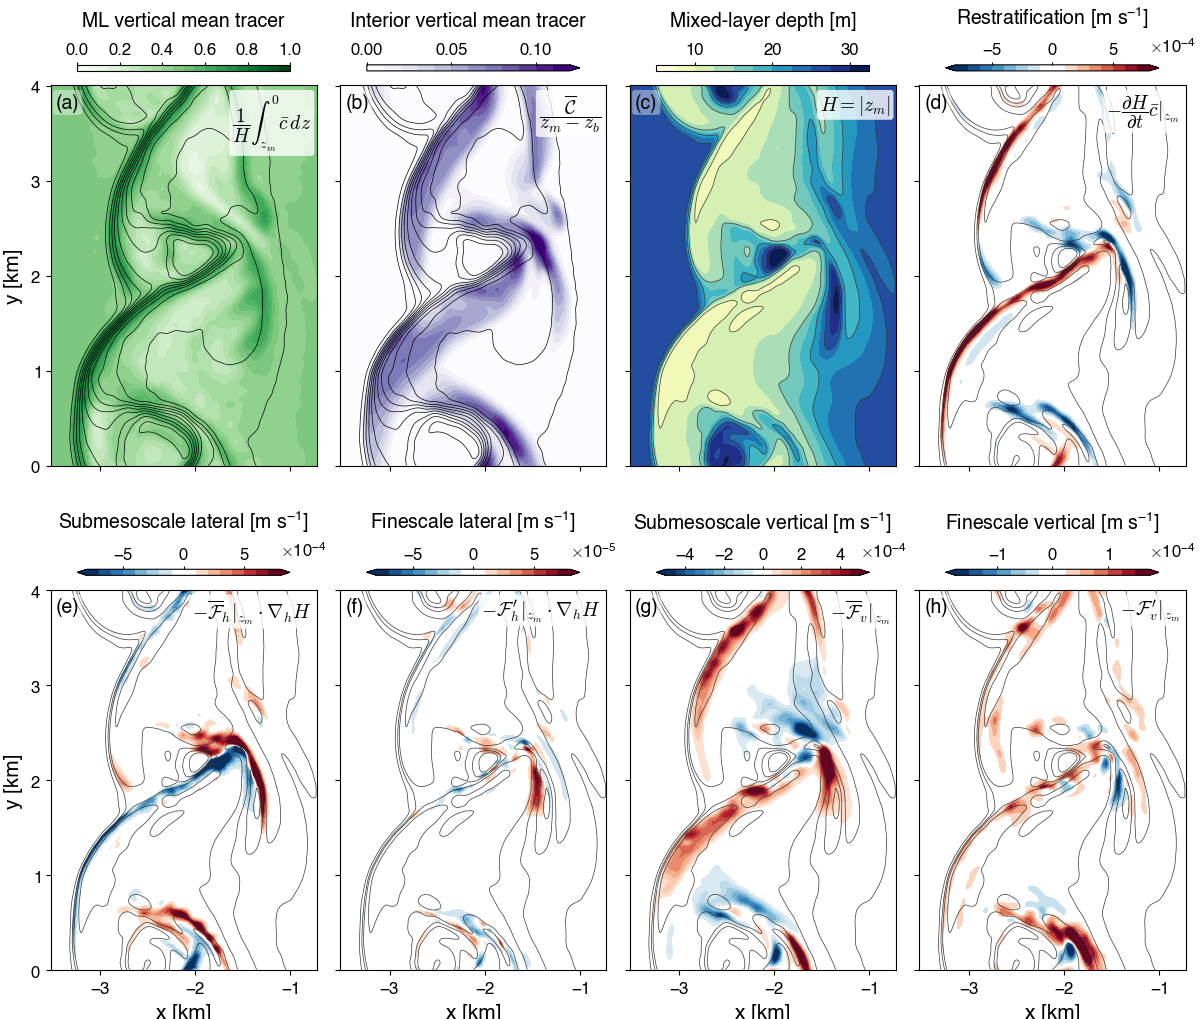

In [20]:
plt.close()
_,ax = plt.subplots(2,4, figsize=(12, 10.2), constrained_layout=True, sharex=True, sharey=True)

# pcm,_ = pcolor_limits(dsf.cint.isel(time=0), cmap='c')
# plt.contour(dsf.xC, dsf.yC, dsf.mask_fz.isel(time=0), [0.5, 1.5], colors='gray', linewidths=1.5)

pcm6,_ = pcolor_limits(c_ml, ax[0,0], cmap=plt.get_cmap('Greens',20), clim=[0, 1])
pcm7,_ = pcolor_limits(c_in, ax[0,1], cmap=plt.get_cmap('Purples',12), clim=[0, 0.12])
pcm0,_ = pcolor_limits(dsf.mld.isel(time=itime), ax[0,2], cmap=plt.get_cmap('YlGnBu',11), clim=[5,32.5])
pcm1,_ = pcolor_center(c_mld_dHdt.isel(time=itime), ax[0,3], cmap=plt.get_cmap('RdBu_r_ds',16), smag=8e-4)
pcm2,_ = pcolor_center(uh_c_mld.isel(time=itime), ax[1,0], cmap=plt.get_cmap('RdBu_r_ds',16), smag=8e-4)
pcm3,_ = pcolor_center(uhc_mld.isel(time=itime),  ax[1,1], cmap=plt.get_cmap('RdBu_r_ds',16), smag=8e-5)
pcm4,_ = pcolor_center(w_c_mld.isel(time=itime), ax[1,2], cmap=plt.get_cmap('RdBu_r_ds',20), smag=5e-4)
pcm5,_ = pcolor_center(wc_mld.isel(time=itime),  ax[1,3], cmap=plt.get_cmap('RdBu_r_ds',14), smag=1.75e-4)

cbar = config_colorbar(pcm6, ax=ax[0,0], sci_notation=False,  location='top', shrink=0.8, aspect=35, pad=0.02, extend='neither')
cbar.ax.xaxis.set_major_locator(mtick.MultipleLocator(0.2))
cbar.set_label(label=r'ML vertical mean tracer', size=14, labelpad=12)

cbar = config_colorbar(pcm7, ax=ax[0,1], sci_notation=False,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=3, extend='max')
cbar.set_label(label=r'Interior vertical mean tracer', size=14, labelpad=12)

cbar = config_colorbar(pcm0, ax=ax[0,2], sci_notation=False, location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6)
cbar.set_label(label=r'Mixed-layer depth [m]', size=14, labelpad=12)

cbar = config_colorbar(pcm1, ax=ax[0,3], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Restratification [m s$\mathregular{^{-1}}$]', size=14, labelpad=12)

cbar = config_colorbar(pcm2, ax=ax[1,0], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Submesoscale lateral [m s$\mathregular{^{-1}}$]', size=14, labelpad=12)

cbar = config_colorbar(pcm3, ax=ax[1,1], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Finescale lateral [m s$\mathregular{^{-1}}$]', size=14, labelpad=12)

cbar = config_colorbar(pcm4, ax=ax[1,2], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Submesoscale vertical [m s$\mathregular{^{-1}}$]', size=14, labelpad=12)

cbar = config_colorbar(pcm5, ax=ax[1,3], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Finescale vertical [m s$\mathregular{^{-1}}$]', size=14, labelpad=12)

txt_str = 'abcdefgh'
lgd_str = [r'$\dfrac{1}{H}\int_{z_m}^{0}\bar{c} \,dz$',
           r'$\dfrac{\overline{\mathcal{C}}}{z_m - z_b}$',
           r'$H=|z_m|$',
           r'$-\dfrac{\partial H}{\partial t} \bar{c}|_{z_m}$',
           r'$-\overline{\mathbf{\mathcal{F}}}_h|_{z_m} \cdot \nabla_h H$',
           r'$-\mathbf{\mathcal{F}}^{\,\prime}_h|_{z_m} \cdot \nabla_h H$',
           r'$-\overline{\mathcal{F}}_v|_{z_m}$',
           r'$-\mathcal{F}^{\,\prime}_v|_{z_m}$']

count = 0
for i in range(2):
    ax[i,0].set_ylabel('y [km]', fontsize=15)
    for j in range(4):
        ax[i,j].set_aspect('equal')
        ax[i,j].text(0.02, 0.98, f'({txt_str[count]})', ha='left', va='top', transform=ax[i,j].transAxes, fontsize=14,
                     bbox=dict(facecolor='w', edgecolor='none', alpha=0.4, boxstyle='round,pad=0.15'))
        ax[i,j].text(0.98, 0.98, f'{lgd_str[count]}', ha='right', va='top', transform=ax[i,j].transAxes, fontsize=14,
                     bbox=dict(facecolor='w', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.15'))
        if count > 1:
            ax[i,j].contour(dsf.xC/1e3, dsf.yC/1e3, dsf.mld.isel(time=itime), np.arange(5,35,5), colors='xkcd:dark grey', linewidths=0.5)
        if i == 1:
            ax[i,j].set_xlabel('x [km]', fontsize=15)
        count += 1

ax[0,0].contour(dsf.xC/1e3, dsf.yC/1e3, dsl.b.isel(zC=-1), blines_upper, colors='k', linewidths=0.5)
ax[0,1].contour(dsf.xC/1e3, dsf.yC/1e3, dsl.b.isel(zC=-1), blines_upper, colors='k', linewidths=0.5)
ax[0,0].set_yticks(np.linspace(0,4,5))
ax[0,0].set_xticks(np.linspace(-4,0,5))
plt.xlim(-3.52, -0.72);

plt.savefig(f'../Figures/{cname}_cint_budget_map.png', dpi=300);

### Compare lateral transport

In [ ]:
plt.close()
_,ax = plt.subplots(1,4, figsize=(12, 5), constrained_layout=True, sharex=True, sharey=True)

pcm0,_ = pcolor_limits(dsf.mld.isel(time=itime), ax[0], cmap=plt.get_cmap('YlGnBu',15), clim=[32.5,70])
pcm1,_ = pcolor_limits(dsf.uh_mld.isel(time=itime), ax[1], cmap=plt.get_cmap('cmo.tempo',11), clim=[0,0.055])
pcm2,_ = pcolor_center(uh_c_mld.isel(time=itime), ax[2], cmap=plt.get_cmap('RdBu_r_ds',16), smag=8e-4)
pcm3,_ = pcolor_center(uhc_mld.isel(time=itime),  ax[3], cmap=plt.get_cmap('RdBu_r_ds',16), smag=8e-5)

cbar = config_colorbar(pcm0, ax=ax[0], sci_notation=False, location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6)
cbar.set_label(label=r'Mixed-layer depth [m]', size=12, labelpad=10)

cbar = config_colorbar(pcm1, ax=ax[1], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6)
cbar.set_label(label=r'Submesoscale horizontal current [m s$\mathregular{^{-1}}$]', size=12, labelpad=10)

cbar = config_colorbar(pcm2, ax=ax[2], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Submesoscale lateral [m s$\mathregular{^{-1}}$]', size=12, labelpad=10)

cbar = config_colorbar(pcm3, ax=ax[3], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Finescale lateral [m s$\mathregular{^{-1}}$]', size=12, labelpad=10)

txt_str = 'efgh'
lgd_str = [r'$H=|z_m|$',
           r'$\overline{u}_h|_{z_m}$',
           r'$-\overline{\mathbf{\mathcal{F}}}_h|_{z_m} \cdot \nabla_h H$',
           r'$-\mathbf{\mathcal{F}}^{\,\prime}_h|_{z_m} \cdot \nabla_h H$']

ax[0].set_ylabel('y [km]', fontsize=12)
for j in range(4):
    ax[j].set_aspect('equal')
    ax[j].text(0.02, 0.98, f'({txt_str[j]})', ha='left', va='top', transform=ax[j].transAxes, fontsize=12,
                 bbox=dict(facecolor='w', edgecolor='none', alpha=0.4, boxstyle='round,pad=0.15'))
    ax[j].text(0.98, 0.98, f'{lgd_str[j]}', ha='right', va='top', transform=ax[j].transAxes, fontsize=12,
                 bbox=dict(facecolor='w', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.15'))
    ax[j].contour(dsf.xC/1e3, dsf.yC/1e3, dsf.mld.isel(time=itime), np.arange(35,70,5), colors='k', linewidths=0.3)
    ax[j].set_xlabel('x [km]', fontsize=12)

ax[0].set_yticks(np.linspace(0,4,5))
ax[0].set_xticks(np.linspace(-4,0,5))
ax[3].set_ylabel('Moderate cooling', fontsize=18, fontweight='bold', labelpad=12)
ax[3].yaxis.set_label_position('right')
plt.xlim(-3.52, -0.72);

plt.savefig(f'../Figures/{cname}_lateral_transport.png', dpi=300);

In [ ]:
plt.close()
_,ax = plt.subplots(1,4, figsize=(12, 5), constrained_layout=True, sharex=True, sharey=True)

pcm0,_ = pcolor_limits(dsf.mld.isel(time=itime), ax[0], cmap=plt.get_cmap('YlGnBu',11), clim=[5,32.5])
pcm1,_ = pcolor_limits(dsf.uh_mld.isel(time=itime), ax[1], cmap=plt.get_cmap('cmo.tempo',11), clim=[0,0.055])
# pcm1,_ = pcolor_limits(dsl.uh.isel(time=itime).sel(zC=-65, method='nearest'), ax[1], cmap=plt.get_cmap('cmo.tempo',11), clim=[0,0.055])
pcm1,_ = pcolor_limits(dsf.uh_mld.isel(time=itime), ax[1], cmap=plt.get_cmap('cmo.tempo',11), clim=[0,0.055])
pcm2,_ = pcolor_center(uh_c_mld.isel(time=itime), ax[2], cmap=plt.get_cmap('RdBu_r_ds',16), smag=8e-4)
pcm3,_ = pcolor_center(uhc_mld.isel(time=itime),  ax[3], cmap=plt.get_cmap('RdBu_r_ds',16), smag=8e-5)

cbar = config_colorbar(pcm0, ax=ax[0], sci_notation=False, location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6)
cbar.set_label(label=r'Mixed-layer depth [m]', size=12, labelpad=10)

cbar = config_colorbar(pcm1, ax=ax[1], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6)
cbar.set_label(label=r'Submesoscale horizontal current [m s$\mathregular{^{-1}}$]', size=12, labelpad=10)

cbar = config_colorbar(pcm2, ax=ax[2], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Submesoscale lateral [m s$\mathregular{^{-1}}$]', size=12, labelpad=10)

cbar = config_colorbar(pcm3, ax=ax[3], sci_notation=True,  location='top', shrink=0.8, aspect=35, pad=0.02, nbins=6, extend='both')
cbar.set_label(label=r'Finescale lateral [m s$\mathregular{^{-1}}$]', size=12, labelpad=10)

txt_str = 'abcd'
lgd_str = [r'$H=|z_m|$',
           r'$\overline{u}_h|_{z_m}$',
           r'$-\overline{\mathbf{\mathcal{F}}}_h|_{z_m} \cdot \nabla_h H$',
           r'$-\mathbf{\mathcal{F}}^{\,\prime}_h|_{z_m} \cdot \nabla_h H$']

ax[0].set_ylabel('y [km]', fontsize=12)
for j in range(4):
    ax[j].set_aspect('equal')
    ax[j].text(0.02, 0.98, f'({txt_str[j]})', ha='left', va='top', transform=ax[j].transAxes, fontsize=12,
                 bbox=dict(facecolor='w', edgecolor='none', alpha=0.4, boxstyle='round,pad=0.15'))
    ax[j].text(0.98, 0.98, f'{lgd_str[j]}', ha='right', va='top', transform=ax[j].transAxes, fontsize=12,
                 bbox=dict(facecolor='w', edgecolor='none', alpha=0.8, boxstyle='round,pad=0.15'))
    ax[j].contour(dsf.xC/1e3, dsf.yC/1e3, dsf.mld.isel(time=itime), np.arange(5,35,5), colors='k', linewidths=0.3)
    ax[j].set_xlabel('x [km]', fontsize=12)

ax[0].set_yticks(np.linspace(0,4,5))
ax[0].set_xticks(np.linspace(-4,0,5))
ax[3].set_ylabel('Weak cooling', fontsize=18, fontweight='bold', labelpad=12)
ax[3].yaxis.set_label_position('right')
plt.xlim(-3.52, -0.72);

plt.savefig(f'../Figures/{cname}_lateral_transport.png', dpi=300);

### Integrated budget

In [65]:
cbgt0 = dsf.cint.sum(['xC', 'yC'])*dxy
cbgt0 = cbgt0 - cbgt0.isel(time=0)
cbgt1 = integrate.cumulative_trapezoid(c_mld_dHdt.sum(['xC', 'yC'])*dxy,  dx=dt, initial=0)
cbgt2 = integrate.cumulative_trapezoid(lateral_mld.sum(['xC', 'yC'])*dxy, dx=dt, initial=0)
cbgt4 = integrate.cumulative_trapezoid(w_c_mld.sum(['xC', 'yC'])*dxy,     dx=dt, initial=0)
cbgt5 = integrate.cumulative_trapezoid(wc_mld.sum(['xC', 'yC'])*dxy,      dx=dt, initial=0)

cbdgt = np.stack([cbgt1, cbgt2, cbgt4, cbgt5])

In [56]:
cbdgt_moderate_cooling = cbdgt.copy()
cbgt0_moderate_cooling = cbgt0.copy()

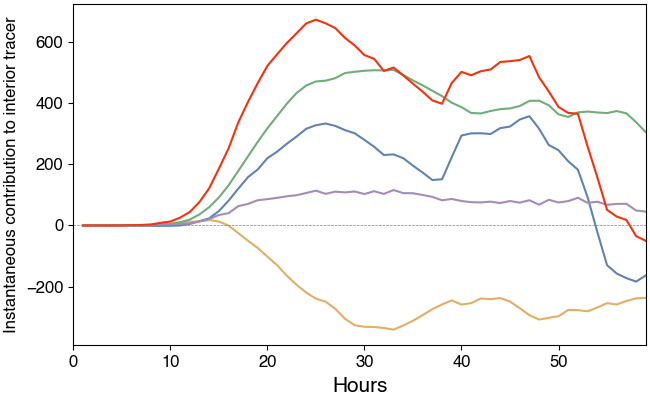

In [16]:
plt.close()
plt.figure(figsize=(6.5,4), constrained_layout=True)

colors = ['#5F84B1', '#E3AE66', '#6FAE7A', '#A48CB8']

plt.plot(dsf.hour, c_mld_dHdt.sum(['xC', 'yC'])*dxy,  c='#5F84B1', linewidth=1.5)
plt.plot(dsf.hour, lateral_mld.sum(['xC', 'yC'])*dxy, c='#E3AE66', linewidth=1.5)
plt.plot(dsf.hour, w_c_mld.sum(['xC', 'yC'])*dxy,     c='#6FAE7A', linewidth=1.5)
plt.plot(dsf.hour, wc_mld.sum(['xC', 'yC'])*dxy,      c='#A48CB8', linewidth=1.5)
plt.plot(dsf.hour, (c_mld_dHdt + lateral_mld + w_c_mld + wc_mld).sum(['xC', 'yC'])*dxy, c='xkcd:vermillion', linewidth=1.5)

plt.axhline(0, ls='--', c='gray', lw=0.5)
plt.ylabel(r'Instantaneous contribution to interior tracer', fontsize=12)
plt.xlabel('Hours')
plt.xlim(0, 59);

In [ ]:
plt.close()
plt.figure(figsize=(6.5,4), constrained_layout=True)

colors = ['#5F84B1', '#E3AE66', '#6FAE7A', '#A48CB8']

for i in range(4):
    plt.plot(dsf.hour, cbdgt[i], c=colors[i], linewidth=1.5)
plt.plot(dsf.hour, cbdgt.sum(axis=0), c='k', linewidth=2.5)
plt.axhline(0, ls='--', c='gray', lw=0.5)
plt.ylabel(r'Cumulative contribution to interior tracer', fontsize=12)
plt.xlabel('Hours')
plt.xlim(0, 59);

In [ ]:
plt.close()
plt.figure(figsize=(6,4), constrained_layout=True)
# plt.figure(figsize=(12,5), constrained_layout=True)

colors = ['#5F84B1', '#E3AE66', '#6FAE7A', '#A48CB8']
# plt.stackplot(dsf.hour, cbdgt[0],  colors=['#5F84B1'],  alpha=0.9, linewidth=1)
plt.stackplot(dsf.hour, cbdgt, colors=colors, alpha=0.9, linewidth=1, clip_on=False, zorder=3)
plt.plot(dsf.hour, cbgt0, 'xkcd:dark', lw=2.5)

labels = ['Restratification', 'Lateral', 'Submesoscale vertical', 'Finescale vertical', 'Interior tracer']
plt.legend(labels, frameon=False, fontsize=12, reverse=True)
ax1 = plt.gca()
ax1.tick_params(axis='both', which='major', labelsize=9, length=4)
ax1.ticklabel_format(axis='y', useMathText=True)
# ax1.spines['top'].set_visible(False)
# ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_linewidth(0.8)
ax1.spines['bottom'].set_linewidth(0.8)
ax1.set_xlim(0, 59)
ax1.set_ylim(0, 1.2e8)
# ax1.set_ylim(0, 3e7)

# ax1.set_ylim(0, 1.4e8)

cint_end = cbgt0[-1].load().data.item()
def val2perc(y):
    return y / cint_end

def perc2val(y):
    return y * cint_end

ax2 = ax1.secondary_yaxis('right', functions=(val2perc, perc2val))
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax2.tick_params(axis='both', which='major', labelsize=9, length=3.5)

plt.ylabel(r'Stacked cumulative contribution [m$\mathregular{^3}$]', fontsize=12)
plt.xlabel('Hour', fontsize=12);
# plt.savefig(f'../Figures/{cname}_cint_budget.png', dpi=900);

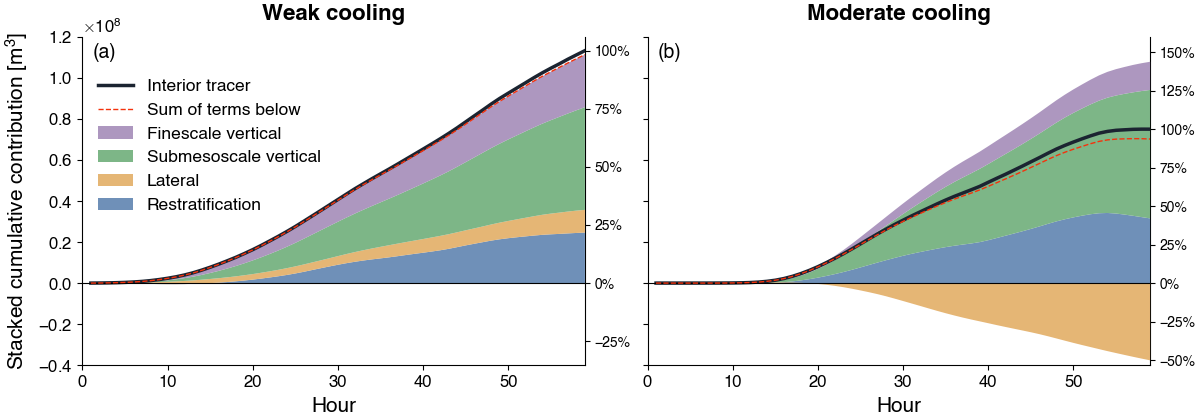

In [67]:
plt.close()
_,ax = plt.subplots(1,2, figsize=(12,4.2), constrained_layout=True, sharex=True, sharey=True)

colors = ['#5F84B1', '#E3AE66', '#6FAE7A', '#A48CB8']

ax[0].stackplot(dsf.hour, cbdgt, colors=colors, alpha=0.9, linewidth=1, clip_on=False, zorder=1)
ax[0].plot(dsf.hour, cbdgt.sum(axis=0), ls='--', c='xkcd:vermillion', linewidth=1, zorder=3)
ax[0].plot(dsf.hour, cbgt0, 'xkcd:dark', lw=2.5, zorder=2)
ax[0].axhline(0, c='k', lw=0.8)

ax[1].stackplot(dsf.hour, cbdgt_moderate_cooling[[0,2,3]], colors=[colors[i] for i in [0,2,3]], alpha=0.9, linewidth=1, clip_on=False, zorder=1)
ax[1].stackplot(dsf.hour, cbdgt_moderate_cooling[1],       colors=[colors[1]],                  alpha=0.9, linewidth=1, clip_on=False, zorder=1)
ax[1].plot(dsf.hour, cbdgt_moderate_cooling.sum(axis=0), ls='--', c='xkcd:vermillion', linewidth=1, zorder=3)
ax[1].plot(dsf.hour, cbgt0_moderate_cooling, 'xkcd:dark', lw=2.5, zorder=2)
ax[1].axhline(0, c='k', lw=0.8)

cint_end = cbgt0[-1].load().data.item()
def val2perc_ax0(y):
    return y / cint_end
def perc2val_ax0(y):
    return y * cint_end
ax[0].tick_params(axis='both', which='major', labelsize=12, length=3.5)
ax[0].ticklabel_format(axis='y', useMathText=True)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)
ax[0].spines['left'].set_linewidth(0.8)
ax[0].spines['bottom'].set_linewidth(0.8)
ax0 = ax[0].secondary_yaxis('right', functions=(val2perc_ax0, perc2val_ax0))
ax0.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax0.yaxis.set_major_locator(mtick.MultipleLocator(0.25))
ax0.tick_params(axis='both', which='major', labelsize=10, length=3.5)

cint_end_moderate_cooling = cbgt0_moderate_cooling[-1].load().data.item()
def val2perc_ax1(y):
    return y / cint_end_moderate_cooling
def perc2val_ax1(y):
    return y * cint_end_moderate_cooling
ax[1].tick_params(axis='both', which='major', labelsize=12, length=3.5)
ax[1].ticklabel_format(axis='y', useMathText=True)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)
ax[1].spines['left'].set_linewidth(0.8)
ax[1].spines['bottom'].set_linewidth(0.8)
ax1 = ax[1].secondary_yaxis('right', functions=(val2perc_ax1, perc2val_ax1))
ax1.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1.0))
ax1.yaxis.set_major_locator(mtick.MultipleLocator(0.25))
ax1.tick_params(axis='both', which='major', labelsize=10, length=3.5)

ax[0].text(0.02, 0.98, '(a)', ha='left', va='top', transform=ax[0].transAxes, fontsize=14)
ax[1].text(0.02, 0.98, '(b)', ha='left', va='top', transform=ax[1].transAxes, fontsize=14)

labels_ax_0 = ['Restratification', 'Lateral', 'Submesoscale vertical', 'Finescale vertical', 'Sum of terms below', 'Interior tracer']
ax[0].legend(labels_ax_0, frameon=False, fontsize=12.5, reverse=True, loc='upper left', bbox_to_anchor=(0, 0.92))
# labels_ax_1 = ['Restratification', 'Submesoscale vertical', 'Finescale vertical', 'Lateral', 'Sum of terms below', 'Interior tracer']
# ax[1].legend(labels_ax_1, frameon=False, fontsize=12, reverse=True, loc='upper left', bbox_to_anchor=(0, 0.9))
ax[0].set_xlim(0, 59)
ax[0].set_ylim(-0.4e8, 1.2e8)
ax[0].set_title('Weak cooling',   fontsize=16, pad=12, fontweight='bold')
ax[1].set_title('Moderate cooling', fontsize=16, pad=12, fontweight='bold')
ax[0].set_ylabel(r'Stacked cumulative contribution [m$\mathregular{^3}$]', fontsize=15)
ax[0].set_xlabel('Hour', fontsize=15)
ax[1].set_xlabel('Hour', fontsize=15);

plt.savefig(f'../Figures/cint_budget.png', dpi=300);